# 01. Life Contingencies: The Pure Endowment Model (${}_{n}E_{x}$)

The **Pure Endowment** is the most fundamental building block of life contingencies. It represents a contract that pays a fixed sum (usually normalized to 1) at a specific future date $n$, provided the policyholder $(x)$ is still alive.

### The Actuarial Formula

The Actuarial Present Value (APV) is calculated by combining financial discounting with the probability of survival:

$${}_{n}E_{x} = v^{n} \cdot {}_{n}p_{x}$$

**Where:**

* $v^{n} = (1 + i)^{-n}$ is the **Financial Discount Factor**, accounting for the time value of money at interest rate $i$.
* ${}_{n}p_{x} = \frac{l_{x+n}}{l_{x}}$ is the **Probability of Survival**, representing the likelihood that an individual aged $x$ reaches age $x+n$ based on a specific mortality table.

### Real-World Application: Education Savings Policies

In the Kenyan insurance market, this model is the core engine for **Education Endowment Products**.

**Scenario:**
A parent in Eldoret wants to secure a payout of **KES 1,000,000** for their child’s university fees in 15 years. The insurance company must determine the "Net Single Premium" to charge today.

By using the Pure Endowment model, the insurer ensures that the premium collected today, when invested at the prevailing **CBK Risk-Free Rate**, will grow to the target amount, while also accounting for the statistical probability that the benefit will actually be paid out (contingent on survival).

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup a Mock Mortality Table (l_x values)
# In a real scenario, you would load a CSV like KE2007 or A8284
ages = np.arange(0, 101)
# Simple De Moivre's Law approximation for lx for demonstration
lx_values = 100000 * (1 - ages/100) 
mortality_table = pd.DataFrame({'age': ages, 'lx': lx_values}).set_index('age')

def calculate_pure_endowment(age, term, interest_rate, table):
    """
    Calculates the Actuarial Present Value of a Pure Endowment.
    """
    if (age + term) > table.index.max():
        return 0.0
    
    # Financial Discounting
    v_n = (1 + interest_rate) ** -term
    
    # Survival Probability (npx)
    lx = table.loc[age, 'lx']
    lx_plus_n = table.loc[age + term, 'lx']
    npx = lx_plus_n / lx
    
    return v_n * npx

# 2. Example Calculation
current_age = 30
policy_term = 20
rate = 0.08 # 8% annual interest

premium = calculate_pure_endowment(current_age, policy_term, rate, mortality_table)
print(mortality_table.head())  # Display the first few rows of the mortality table for verification
print(f"\nFor a benefit of 1 unit:")
print(f"The Net Single Premium for a {current_age}-year old over a {policy_term}-year term is: {premium:.5f}")

           lx
age          
0    100000.0
1     99000.0
2     98000.0
3     97000.0
4     96000.0

For a benefit of 1 unit:
The Net Single Premium for a 30-year old over a 20-year term is: 0.15325


### Visualization of Sensitivity

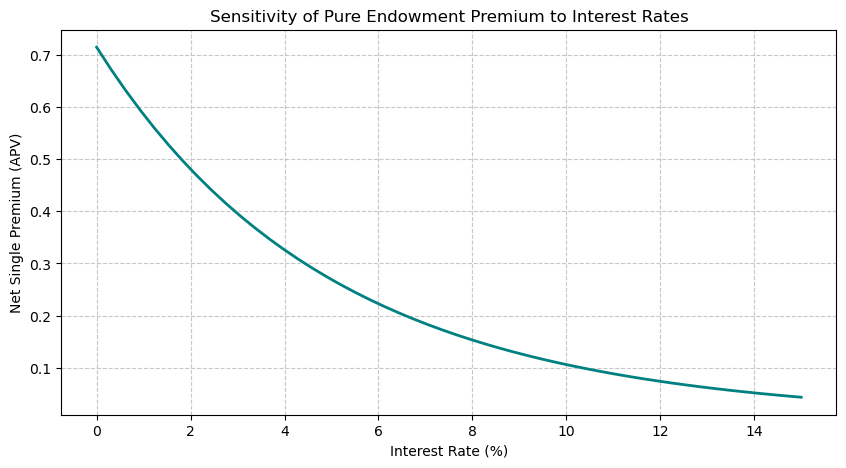

In [2]:
# 3. Visualizing how Interest Rates affect the Premium
rates = np.linspace(0, 0.15, 50) # 0% to 15%
premiums = [calculate_pure_endowment(30, 20, r, mortality_table) for r in rates]

plt.figure(figsize=(10, 5))
plt.plot(rates * 100, premiums, color='teal', linewidth=2)
plt.title('Sensitivity of Pure Endowment Premium to Interest Rates')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Net Single Premium (APV)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Parting Shot: Real-World Applications Beyond Education

While we focused on education policies, the **Pure Endowment** concept, the principle of "payment contingent on survival", is a fundamental building block across several high-value domains:

-   **Mortgage Protection (Low-Cost Endowments):** Many homeowners take out pure endowment policies that mature exactly when their mortgage ends. If they survive the term, the payout is used to clear the final principal of the loan.
    
-   **Executive Compensation & Retention:** Large firms use "Golden Handcuffs", a pure endowment structure where a high-performing executive receives a massive bonus only if they remain with the company (survive professionally) for a set number of years (e.g., a 5-year vesting period).
    
-   **Pension Fund "Return of Premium" Riders:** Some pension schemes use pure endowment calculations to determine the cost of adding a "survivorship bonus" to a pool of retirees. It helps in redistributing the funds of those who pass away early to those who live longer.
    
-   **Estate Planning & Wealth Transfer:** It is often used as a risk-free tool for transferring wealth to the next generation at a specific age (e.g., a child’s 25th birthday), ensuring the capital is preserved and only released when the beneficiary is likely to have reached financial maturity.
    
-   **Corporate Debt Redemption:** Companies often set up "Sinking Funds" based on pure endowment principles to ensure they have the cash to pay off corporate bonds upon maturity, provided the business entity remains solvent (the corporate version of "survival").